# ***TRATAMIENTO DE LAS PROBLEMÁTICAS***

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from imblearn.over_sampling import SMOTE
import seaborn as sns
import shap

In [7]:
df = pd.read_csv('../data/diabetes_preprocesado.csv', sep=",", quotechar='"')

y = df["readmitted"]
X = df.drop(columns=["readmitted"])

X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

## 1- Datos desbalanceados

El dataset presenta una distribución desigual en la variable objetivo **"readmitted"**, lo que convierte el desbalanceo de clases en una problemática central del proyecto. En concreto, los casos de reingreso temprano aparecen en menor proporción que el resto, pese a ser precisamente los más importantes desde el punto de vista clínico. Esto puede hacer que el modelo aprenda patrones que beneficien a las clases mayoritarias y reduzca su capacidad para detectar pacientes que realmente podrían necesitar un mayor seguimiento. En este caso, el problema no es solo técnico, ya que ignorar a la clase minoritaria puede implicar no identificar a pacientes con riesgo elevado de volver a ingresar, lo que afectaría tanto a su salud como a la planificación de recursos del hospital.

Antes de SMOTE:
readmitted
0    41870
1    27719
2     8853
Name: count, dtype: int64

Después de SMOTE:
readmitted
0    41870
1    41870
2    41870
Name: count, dtype: int64


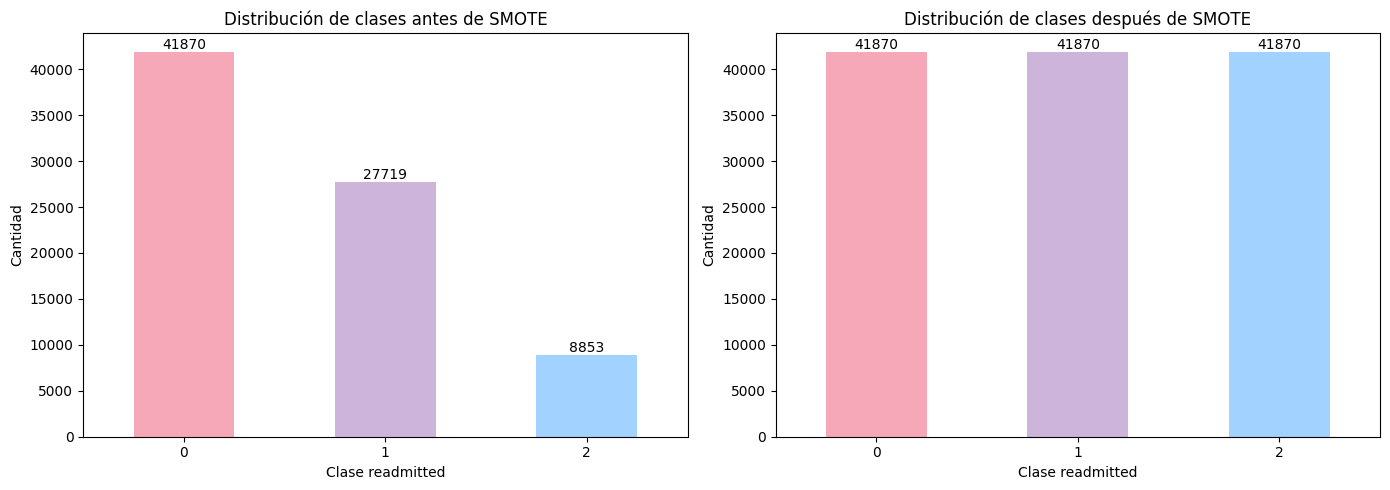

In [3]:
# Distribución antes de SMOTE
y_train_counts = pd.Series(y_train).value_counts()

print("Antes de SMOTE:")
print(y_train_counts)

# Aplicar SMOTE solo al entrenamiento
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)


# Distribución después de SMOTE
y_train_smote_counts = pd.Series(y_train_smote).value_counts()

print("\nDespués de SMOTE:")
print(y_train_smote_counts)

# Gráfica comparativa
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#F7A8B8', '#CDB4DB', '#A2D2FF']  # rosa, lila, azul pastel

# Antes
y_train_counts.plot(
    kind='bar',
    ax=axes[0],
    color=colors
)

axes[0].set_title("Distribución de clases antes de SMOTE")
axes[0].set_xlabel("Clase readmitted")
axes[0].set_ylabel("Cantidad")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

for p in axes[0].patches:
    axes[0].annotate(
        int(p.get_height()),
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center',
        va='bottom'
    )

# Después
y_train_smote_counts.plot(
    kind='bar',
    ax=axes[1],
    color=colors
)

axes[1].set_title("Distribución de clases después de SMOTE")
axes[1].set_xlabel("Clase readmitted")
axes[1].set_ylabel("Cantidad")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

for p in axes[1].patches:
    axes[1].annotate(
        int(p.get_height()),
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.savefig("../visualizacion_problematicas/smote_distribucion_clases.png", dpi=300, bbox_inches="tight")
plt.show()

Antes de aplicar ninguna técnica de balanceo, la distribución de clases en el conjunto de entrenamiento era muy desigual. Como se observa en la imagen, la clase mayoritaria contiene 41.870 instancias, mientras que las otras clases tienen 27.719 y 8.853 instancias, respectivamente. Esto significa que el modelo dispone de muchos más ejemplos de unas clases que de otras. Esta situación es habitual en problemas clínicos reales, ya que los eventos de mayor interés, como un reingreso temprano, suelen producirse con menor frecuencia.

Como se ha comentado, este desbalanceo es importante porque puede afectar directamente al comportamiento del modelo. Si se entrena un clasificador sobre estos datos, el modelo puede aprender a favorecer las clases mayoritarias, ya que esto le permite obtener buenos resultados sin identificar correctamente los casos menos frecuentes. Como se ha visto durante las fases anteriores de entrenamiento de modelos, una métrica como accuracy puede resultar engañosa, porque un modelo puede alcanzar una precisión aparentemente alta simplemente clasificando correctamente la clase mayoritaria. Sin embargo, al analizar métricas más informativas como el F1-score, se veía que el rendimiento era peor y que el modelo no estaba aprendiendo de forma equilibrada todas las categorías, sino que el desbalanceo estaba afectando a su capacidad para detectar correctamente los casos minoritarios.

En el contexto del problema esto es crítico, ya que un falso negativo, es decir, clasificar como bajo riesgo a un paciente que finalmente será readmitido en menos de 30 días, puede provocar que no reciba seguimiento adicional cuando realmente sí lo necesitaba. Esto puede aumentar el riesgo de complicaciones para el paciente y generar nuevos costes hospitalarios. 

Para tratar el desbalanceo de clases se ha utilizado la técnica SMOTE, que genera ejemplos sintéticos de las clases minoritarias a partir de muestras reales cercanas para equilibrar la distribución de clases. Esto se ha aplicado sobre el conjunto de entrenamiento para evitar data leakage. Si se aplicara antes de separar entrenamiento y test, las muestras sintéticas podrían generarse usando información de datos que después quedarían en el test. Esto haría que el modelo fuese evaluado con datos indirectamente parecidos a los que ya ha visto durante el entrenamiento, dando resultados demasiado optimistas.

Como resultado, tras aplicar SMOTE, las tres clases de quedan equilibradas con 41.870 instancias cada una en el conjunto de entrenamiento. Este resultado se observa claramente en la gráfica comparativa. Antes del tratamiento, la distribución estaba dominada por la clase 0, mientras que la clase 2 tenía una presencia mucho menor. Después de aplicar SMOTE, las tres barras tienen la misma altura, lo que confirma que el conjunto de entrenamiento ha quedado balanceado. De esta forma, durante el aprendizaje, el modelo no se ve tan condicionado por la frecuencia original de las clases.

## 2- Sesgo y Fairness

Para esta segunda problematica se ha decidido centrar el análisis de **Sesgo y Fairness** en las variables de raza, género y edad debido a que son datos sensibles, tanto desde una perspectiva legal como ética en el ámbito sanitario. A diferencia de las variables clínicas, como los niveles de glucosa o el tipo de medicación, que poseen una relación biológica con la posibilidad de readmisión, los atributos sociodemográficos no deberían determinar por sí mismos el resultado de la atención médica. El objetivo de este análisis no es encontrar correlaciones estadístivas generales en todo el dataset, sino identificar sesgos injustos o históricos que el modelo podría heredar y amplificar, asegurando así que el sistema de inteligencia artificial sea equitativo y no discrimine a grupos vulnerables al realizar predicciones que afectan a la salud de las personas.

De esta forma, se analiza la distribución de la variable objetivo (*readmitted*) a través de estas variables sensibles (race, gender, age). Si un grupo tiene una tasa de readmisión históricamente mucho más alta o baja, el modelo "heredará" este sesgo.

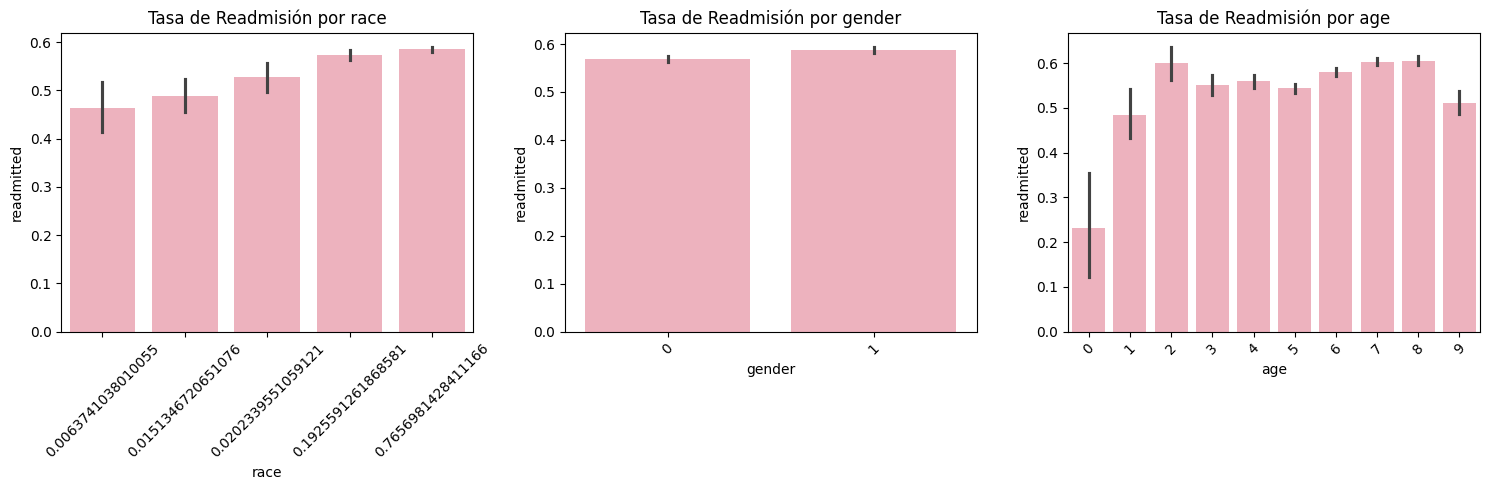

In [ ]:
atributos_sensibles = ['race', 'gender', 'age']

plt.figure(figsize=(15, 5))

for i, col in enumerate(atributos_sensibles):
    plt.subplot(1, 3, i+1)
    sns.barplot(x=col, y='readmitted', data=df, color='#F7A8B8')
    plt.title(f'Tasa de Readmisión por {col}')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [15]:
def calcular_impacto_dispar(df, columna_sensible):
    tasas = df.groupby(columna_sensible)['readmitted'].mean()
    
    valor_privilegiado = tasas.idxmin()
    valor_no_privilegiado = tasas.idxmax()
    
    prob_priv = tasas.min()
    prob_no_priv = tasas.max()
    
    if prob_priv == 0:
        return 0, valor_privilegiado, valor_no_privilegiado
        
    impacto_dispar = prob_no_priv / prob_priv
    return impacto_dispar, valor_privilegiado, valor_no_privilegiado

variables_sensibles = ['gender', 'race', 'age']

print("--- ANÁLISIS DE IMPACTO DISPAR ---")
for var in variables_sensibles:
    id_val, priv, no_priv = calcular_impacto_dispar(df, var)
    
    print(f"\nVariable: {var}")
    print(f"  - Grupo con menor riesgo (Privilegiado): {priv}")
    print(f"  - Grupo con mayor riesgo (No Privilegiado): {no_priv}")
    print(f"  - Ratio de Impacto Dispar: {id_val:.4f}")
    
    # Interpretación de la Regla del 80% (o 1.25 en este caso por ser ratio de riesgo)
    if id_val > 1.25:
        print(f"  Existe un sesgo significativo. El grupo {no_priv} tiene un {((id_val-1)*100):.1f}% más de riesgo de readmisión que el grupo {priv}.")
    else:
        print(f" El sesgo parece estar dentro de los límites aceptables (inferior al 25% de diferencia).")

--- ANÁLISIS DE IMPACTO DISPAR ---

Variable: gender
  - Grupo con menor riesgo (Privilegiado): 0
  - Grupo con mayor riesgo (No Privilegiado): 1
  - Ratio de Impacto Dispar: 1.0339
 El sesgo parece estar dentro de los límites aceptables (inferior al 25% de diferencia).

Variable: race
  - Grupo con menor riesgo (Privilegiado): 0.0063741038010055
  - Grupo con mayor riesgo (No Privilegiado): 0.7656981428411166
  - Ratio de Impacto Dispar: 1.2645
  Existe un sesgo significativo. El grupo 0.7656981428411166 tiene un 26.4% más de riesgo de readmisión que el grupo 0.0063741038010055.

Variable: age
  - Grupo con menor riesgo (Privilegiado): 0
  - Grupo con mayor riesgo (No Privilegiado): 8
  - Ratio de Impacto Dispar: 2.6230
  Existe un sesgo significativo. El grupo 8 tiene un 162.3% más de riesgo de readmisión que el grupo 0.


En primer lugar, la variable **`gender`** presenta una situación de equidad casi ideal. Con un ratio de impacto dispar de **1.0339**, la diferencia de riesgo entre hombres y mujeres (grupos 0 y 1) es de apenas un **3.4%**. Este valor cae muy por debajo del umbral crítico del 25%, lo que indica que, para este dataset, el género no es un factor que introduzca una discriminación significativa de forma aislada. Por tanto, no requiere de medidas de mitigación.

Por el contrario, la variable **`race`** (raza) sí muestra un sesgo que supera los límites éticos aceptables. El grupo identificado con el valor `0.7656` presenta un **26.4% más de riesgo** de ser readmitido que el grupo de referencia. Este ratio de **1.2645** sobrepasa la "regla del 80%" (su inverso de 1.25), lo que sugiere que el modelo podría aprender a penalizar a ciertos grupos étnicos. Gestionar este sesgo es prioritario para evitar que el sistema presente desigualdades históricas en el acceso o la calidad de la atención médica.

Finalmente, la variable **`age`** (edad) presenta el caso más crítico y complejo, con un ratio de impacto dispar de **2.6230**. Esto significa que los pacientes del grupo de mayor edad (grupo 8) tienen un **162.3% más de riesgo** de readmisión que los del grupo más joven. Aunque en medicina la edad es un factor de riesgo clínico legítimo, una diferencia tan abismal indica que el modelo podría volverse dependiente de esta variable, ignorando otros indicadores médicos importantes. Trataremos esta variable para asegurar que el modelo sea robusto y no diagnostique "por edad", sino por la condición clínica real del paciente.

In [19]:
def calcular_pesos_fairness(df, columna_sensible, target):
    # Calculamos las probabilidades globales
    n = len(df)
    n_readmitted = df[target].sum()
    n_not_readmitted = n - n_readmitted
    
    weights = pd.Series(1.0, index=df.index)
    
    for grupo in df[columna_sensible].unique():
        # Subconjunto del grupo
        mask_grupo = (df[columna_sensible] == grupo)
        n_g = mask_grupo.sum()
        
        # Subconjunto del grupo y su resultado
        for label in [0, 1]:
            mask_label = (df[target] == label)
            n_gl = (mask_grupo & mask_label).sum()
            
            if n_gl > 0:
                # Fórmula de Re-weighting: (P(L) * P(G)) / P(G & L)
                # Proporción esperada si fueran independientes / Proporción observada
                proporcion_esperada = ( (n_readmitted if label==1 else n_not_readmitted) / n ) * (n_g / n)
                proporcion_real = n_gl / n
                
                weights.loc[mask_grupo & mask_label] = proporcion_esperada / proporcion_real
                
    return weights

# Aplicamos el cálculo para las dos variables problemáticas
weights_race = calcular_pesos_fairness(df, 'race', 'readmitted')
weights_age = calcular_pesos_fairness(df, 'age', 'readmitted')

# Combinamos los pesos
df['sample_weight'] = (weights_race + weights_age) / 2

print("Pesos generados correctamente. Valores min:", df['sample_weight'].min(), "max:", df['sample_weight'].max())

Pesos generados correctamente. Valores min: 0.5962502520025983 max: 2.283238449026199


Para gestionar esta problemática, hemos implementado una estrategia de mitigación que actúa directamente sobre la importancia que el modelo otorga a cada registro. Esta solución se basa en la creación de una nueva columna denominada **`sample_weight`**. Esta variable no es una característica clínica que el modelo deba usar para predecir, sino una herramienta de ajuste ético. Se genera mediante el cálculo de la probabilidad esperada de readmisión frente a la observada para cada grupo sensible. Al asignar un peso mayor a los casos que contradicen el sesgo histórico (por ejemplo, pacientes jóvenes readmitidos o pacientes de grupos raciales específicos no readmitidos), logramos "equilibrar la balanza" sin necesidad de eliminar datos valiosos, permitiendo que el algoritmo aprenda patrones médicos reales.

A la hora de preparar los datos para el entrenamiento, es fundamental que esta columna de pesos se trate de forma sincronizada con el resto del dataset. Al utilizar la función `train_test_split`, debemos incluir `sample_weight` como un tercer elemento de división junto a las características (`X`) y la variable objetivo (`y`). Esto garantiza que cada registro en el conjunto de entrenamiento mantenga asociado su peso correspondiente (`w_train`), preservando la integridad de la corrección del sesgo durante la fase de aprendizaje.

Finalmente, la aplicación práctica de esta técnica se realiza en el momento del entrenamiento. Al invocar el método `.fit()` de un modelo, se debe pasar el parámetro `sample_weight=w_train`. Con esto, el optimizador del modelo dará más importancia a los errores cometidos en ejemplos clave para la equidad, resultando en un sistema que no solo es preciso, sino que cumple con los estándares éticos y legales de imparcialidad requeridos.

## 2- Explicabilidad

## 3- Privacidad y Federated Learning

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, precision_score, recall_score
from sklearn.utils.class_weight import compute_sample_weight

In [40]:
X_train_np = X_train.to_numpy() if hasattr(X_train, "to_numpy") else np.asarray(X_train)
X_test_np = X_test.to_numpy() if hasattr(X_test, "to_numpy") else np.asarray(X_test)

y_train_np = y_train.to_numpy() if hasattr(y_train, "to_numpy") else np.asarray(y_train)
y_test_np = y_test.to_numpy() if hasattr(y_test, "to_numpy") else np.asarray(y_test)

classes = np.unique(y_train_np)

In [41]:
def crear_clientes_federados(X, y, n_clients=5, random_state=42):
    skf = StratifiedKFold(
        n_splits=n_clients,
        shuffle=True,
        random_state=random_state
    )

    clientes = []

    for _, client_idx in skf.split(X, y):
        X_client = X[client_idx]
        y_client = y[client_idx]
        clientes.append((X_client, y_client))

    return clientes


n_clients = 5

clientes = crear_clientes_federados(
    X_train_np,
    y_train_np,
    n_clients=n_clients,
    random_state=42
)

In [42]:
def agregar_parametros_fedavg(parametros_clientes, tamanos_clientes):
    total_muestras = np.sum(tamanos_clientes)

    coef_global = np.zeros_like(parametros_clientes[0][0])
    intercept_global = np.zeros_like(parametros_clientes[0][1])

    for (coef_cliente, intercept_cliente), n_cliente in zip(parametros_clientes, tamanos_clientes):
        peso = n_cliente / total_muestras
        coef_global += peso * coef_cliente
        intercept_global += peso * intercept_cliente

    return coef_global, intercept_global

def entrenar_cliente(
    X_client,
    y_client,
    coef_global,
    intercept_global,
    classes,
    local_epochs=1,
    random_state=42
):
    modelo_local = SGDClassifier(
        loss="log_loss",
        penalty="l2",
        alpha=0.0001,
        learning_rate="optimal",
        max_iter=1,
        tol=None,
        random_state=random_state
    )

    X_dummy = np.zeros((len(classes), X_client.shape[1]))
    y_dummy = classes

    modelo_local.partial_fit(X_dummy, y_dummy, classes=classes)

    modelo_local.coef_ = coef_global.copy()
    modelo_local.intercept_ = intercept_global.copy()

    sample_weights = compute_sample_weight(
        class_weight="balanced",
        y=y_client
    )

    rng = np.random.default_rng(random_state)

    for _ in range(local_epochs):
        indices = rng.permutation(len(y_client))

        modelo_local.partial_fit(
            X_client[indices],
            y_client[indices],
            classes=classes,
            sample_weight=sample_weights[indices]
        )

    return modelo_local.coef_, modelo_local.intercept_

def inicializar_modelo_global(n_features, classes):
    modelo = SGDClassifier(
        loss="log_loss",
        penalty="l2",
        alpha=0.0001,
        learning_rate="optimal",
        max_iter=1,
        tol=None,
        random_state=42
    )

    X_dummy = np.zeros((len(classes), n_features))
    y_dummy = classes

    modelo.partial_fit(X_dummy, y_dummy, classes=classes)

    modelo.coef_ = np.zeros_like(modelo.coef_)
    modelo.intercept_ = np.zeros_like(modelo.intercept_)

    return modelo

In [46]:
n_features = X_train_np.shape[1]
n_rounds = 20
local_epochs = 1

modelo_global = inicializar_modelo_global(
    n_features=n_features,
    classes=classes
)

historial_federado = []

for ronda in range(1, n_rounds + 1):
    parametros_clientes = []
    tamanos_clientes = []

    for client_id, (X_c, y_c) in enumerate(clientes):
        coef_c, intercept_c = entrenar_cliente(
            X_client=X_c,
            y_client=y_c,
            coef_global=modelo_global.coef_,
            intercept_global=modelo_global.intercept_,
            classes=classes,
            local_epochs=local_epochs,
            random_state=42 + ronda + client_id
        )

        parametros_clientes.append((coef_c, intercept_c))
        tamanos_clientes.append(len(y_c))

    coef_global, intercept_global = agregar_parametros_fedavg(
        parametros_clientes,
        tamanos_clientes
    )

    modelo_global.coef_ = coef_global
    modelo_global.intercept_ = intercept_global

    y_pred_ronda = modelo_global.predict(X_test_np)

    historial_federado.append({
        "Ronda": ronda,
        "Accuracy": accuracy_score(y_test_np, y_pred_ronda),
        "Precision Macro": precision_score(
            y_test_np,
            y_pred_ronda,
            average="macro",
            zero_division=0
        ),
        "Recall Macro": recall_score(
            y_test_np,
            y_pred_ronda,
            average="macro",
            zero_division=0
        ),
        "F1-Score Macro": f1_score(
            y_test_np,
            y_pred_ronda,
            average="macro",
            zero_division=0
        ),
        "F1 Weighted": f1_score(
            y_test_np,
            y_pred_ronda,
            average="weighted",
            zero_division=0
        )
    })

historial_federado_df = pd.DataFrame(historial_federado)

# Evaluación final tras la última ronda
y_pred_federado = modelo_global.predict(X_test_np)

resultados_sgd_federado = pd.DataFrame({
    "Modelo": ["SGDClassifier federado"],
    "Escenario": [f"Federated Learning con {n_clients} clientes simulados"],
    "Test Accuracy": [
        accuracy_score(y_test_np, y_pred_federado)
    ],
    "Precision Macro": [
        precision_score(
            y_test_np,
            y_pred_federado,
            average="macro",
            zero_division=0
        )
    ],
    "Recall Macro": [
        recall_score(
            y_test_np,
            y_pred_federado,
            average="macro",
            zero_division=0
        )
    ],
    "F1-Score Macro": [
        f1_score(
            y_test_np,
            y_pred_federado,
            average="macro",
            zero_division=0
        )
    ],
    "F1 Weighted": [
        f1_score(
            y_test_np,
            y_pred_federado,
            average="weighted",
            zero_division=0
        )
    ]
})

resultados_sgd_federado = resultados_sgd_federado.round(4)

resultados_sgd_federado

,Modelo,Escenario,Test Accuracy,Precision Macro,Recall Macro,F1-Score Macro,F1 Weighted
0,SGDClassifier federado,Federated Learning con 5 clientes simulados,0.1373,0.1847,0.3359,0.1196,0.0791


In [47]:
# MODELO CENTRALIZADO EQUIVALENTE
modelo_centralizado = SGDClassifier(
    loss="log_loss",
    penalty="l2",
    alpha=0.0001,
    learning_rate="optimal",
    max_iter=1000,
    tol=1e-3,
    random_state=42
)

sample_weights_train = compute_sample_weight(
    class_weight="balanced",
    y=y_train_np
)

modelo_centralizado.fit(
    X_train_np,
    y_train_np,
    sample_weight=sample_weights_train
)

y_pred_centralizado = modelo_centralizado.predict(X_test_np)

resultados_sgd_centralizado = pd.DataFrame({
    "Modelo": ["SGDClassifier centralizado"],
    "Escenario": ["Datos centralizados"],
    "Test Accuracy": [
        accuracy_score(y_test_np, y_pred_centralizado)
    ],
    "Precision Macro": [
        precision_score(
            y_test_np,
            y_pred_centralizado,
            average="macro",
            zero_division=0
        )
    ],
    "Recall Macro": [
        recall_score(
            y_test_np,
            y_pred_centralizado,
            average="macro",
            zero_division=0
        )
    ],
    "F1-Score Macro": [
        f1_score(
            y_test_np,
            y_pred_centralizado,
            average="macro",
            zero_division=0
        )
    ],
    "F1 Weighted": [
        f1_score(
            y_test_np,
            y_pred_centralizado,
            average="weighted",
            zero_division=0
        )
    ]
})

resultados_sgd_centralizado = resultados_sgd_centralizado.round(4)

resultados_sgd_centralizado

,Modelo,Escenario,Test Accuracy,Precision Macro,Recall Macro,F1-Score Macro,F1 Weighted
0,SGDClassifier centralizado,Datos centralizados,0.1135,0.1451,0.3315,0.0693,0.0259


In [48]:
resultados_privacidad = pd.concat(
    [
        resultados_sgd_centralizado,
        resultados_sgd_federado
    ],
    ignore_index=True
)

resultados_privacidad = resultados_privacidad.round(4)

resultados_privacidad

,Modelo,Escenario,Test Accuracy,Precision Macro,Recall Macro,F1-Score Macro,F1 Weighted
0,SGDClassifier centralizado,Datos centralizados,0.1135,0.1451,0.3315,0.0693,0.0259
1,SGDClassifier federado,Federated Learning con 5 clientes simulados,0.1373,0.1847,0.3359,0.1196,0.0791
